# HR Salary Analysis — Class Recap
## What we covered last class and what comes next

---

## ✅ Questions we already answered

**Section 1 — First Look**
- How many salary records are there?
- How many unique workers?
- What years does the data cover?
- How many position levels and departments exist?

**Section 2 — First Questions (no join needed)**
- Who has the highest net salary? → `sort_values` and `nlargest`
- Who gets the highest bonus?
- Who has been at the company the longest?

**Section 3 — Why Comparisons Need Context**
- What is the overall average salary? *(and why it is misleading)*
- What is the average salary per position level? *(the fair comparison)*


---

## 🔲 Questions still to answer today
**Section 4 — Salary by Department**
- Which department has the highest average salary?
- Is that difference explained by position level? *(confounding variable)*
- Fair comparison: Analysts only across departments
- Salary by area (Technology, Business, Operations, Commercial)

**Section 5 — Salary Evolution Over Time**
- How did average salary change year by year?
- Senior Analysts only — fair time comparison
- Line chart per department — which team grew fastest?

**Section 6 — Career Progression**
- Which workers got promoted?
- Who got promoted the most times?
- What does a specific worker's career path look like?
- How to see multiple workers or a range of IDs at once?

**Section 7 — Tenure Analysis**
- Do workers who stay longer earn more?
- Is the salary difference explained by position level or genuinely by tenure?
- Fair comparison: same level, different tenure group

**Section 8 — Challenges**
- Challenge 1: Which worker earned the most in total across all years?
- Challenge 2: Which department pays the highest average bonus?
- Challenge 3: How many workers were hired each year?

---

> *Run the setup cell first — it reloads all four files and recreates the joined table.*

# HR Salary Analysis
### A dataset you have never seen before — explore it yourself

You have four files:
- `hr_salary_records.csv` — the fact table (one row per worker per year)
- `hr_workers.csv` — worker personal and contract info
- `hr_positions.csv` — position levels and salary bands
- `hr_departments.csv` — department and area info

**How we work today:**
- We join dimension tables only when we need them to answer a question
- Every calculation gets its own variable
- Every print is a separate step
- When comparing salaries — always ask: *does this comparison make sense?*

# 0. Setup

In [1]:
# ── Run this first — reloads everything from last class ────────

# ── Google Colab ───────────────────────────────────────────
# from google.colab import files
# files.upload()   # upload all four CSV files

# ── VS Code ─────────────────────────────────────────────────
# Make sure all four CSV files are in the same folder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all four files
salary  = pd.read_csv("hr_salary_records.csv")
workers = pd.read_csv("hr_workers.csv")
pos     = pd.read_csv("hr_positions.csv")
depts   = pd.read_csv("hr_departments.csv")

# Recreate joins from last class
hr = salary.merge(pos,   on="position_id",   how="left")
hr = hr.merge(depts,     on="department_id",  how="left")

# Calculate tenure
workers["admission_date"]   = pd.to_datetime(workers["admission_date"])
workers["years_at_company"] = ((pd.Timestamp("today") - workers["admission_date"]).dt.days / 365).round(1)

print("Everything loaded and joined!")
print("salary shape: ", salary.shape)
print("hr shape:     ", hr.shape)
print()
print("Columns in hr:")
print(hr.columns.tolist())

Everything loaded and joined!
salary shape:  (151, 11)
hr shape:      (151, 18)

Columns in hr:
['record_id', 'worker_id', 'department_id', 'position_id', 'year', 'base_salary', 'bonus', 'additional_allowance', 'gross_total', 'taxes', 'net_salary', 'position_name', 'level', 'salary_band_min', 'salary_band_max', 'department_name', 'area', 'cost_center']


# 1. First Look — 10 Minutes, You Work Alone
No hints yet. Use the four commands you know.
Look at each table before doing anything else.

## 1.1 — Explore the fact table

In [2]:
salary.shape

(151, 11)

In [3]:
salary.head(10)

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,54994.0
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,15222.0
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,15824.0
5,R0006,W003,D02,P02,2024,15200.0,0.0,2400,17600.0,2464.0,15136.0
6,R0007,W004,D07,P06,2020,58900.0,2500.0,1200,62600.0,20032.0,42568.0
7,R0008,W004,D07,P06,2021,60700.0,1900.0,2400,65000.0,20800.0,44200.0
8,R0009,W005,D06,P07,2019,54800.0,3700.0,2400,60900.0,19488.0,41412.0
9,R0010,W005,D06,P07,2020,56400.0,3500.0,2400,62300.0,19936.0,42364.0


In [4]:
salary.dtypes

record_id                object
worker_id                object
department_id            object
position_id              object
year                      int64
base_salary             float64
bonus                   float64
additional_allowance      int64
gross_total             float64
taxes                   float64
net_salary              float64
dtype: object

In [5]:
salary.describe()

,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,2021.860927,52211.920530,3169.536424,3178.807947,58560.264901,20150.874172,38409.390728
std,1.705050,27850.701792,4160.704962,4104.511490,34590.376464,16001.982546,18739.500013
min,2018.000000,12700.000000,0.000000,0.000000,12700.000000,1778.000000,10922.000000
25%,2021.000000,30300.000000,0.000000,600.000000,31150.000000,7476.000000,23674.000000
50%,2022.000000,53500.000000,2000.000000,1200.000000,58000.000000,18560.000000,39440.000000
75%,2023.000000,68950.000000,3900.000000,4200.000000,76650.000000,29127.000000,48941.000000
max,2024.000000,117700.000000,23700.000000,18000.000000,149800.000000,62916.000000,86884.000000


## 1.2 — Explore the workers table

In [6]:
workers.head(10)

,worker_id,full_name,gender,nationality,date_of_birth,admission_date,end_date,is_active,department_id,years_at_company
0,W001,Alice Wagner,Female,Italian,1976-06-03,2022-05-17,2024-04-18,False,D04,4.1
1,W002,Tina Becker,Female,French,1998-10-19,2023-03-12,NaN,True,D08,3.2
2,W003,Olivia Richter,Female,Brazilian,2000-07-07,2024-10-11,NaN,True,D02,1.7
3,W004,Sofia Braun,Female,Indian,1988-06-14,2020-02-05,2021-11-21,False,D07,6.3
4,W005,Kate Hoffmann,Female,Brazilian,1978-01-13,2019-03-17,2021-04-07,False,D06,7.2
5,W006,Yara Schwarz,Female,Italian,1989-03-14,2018-08-05,NaN,True,D03,7.8
6,W007,Lukas Hartmann,Male,German,1982-02-15,2018-07-21,NaN,True,D02,7.9
7,W008,Max Hoffmann,Male,Spanish,1992-01-03,2024-09-01,NaN,True,D04,1.8
8,W009,Bob Krüger,Male,German,1990-08-07,2024-08-01,NaN,True,D07,1.9
9,W010,Uma Lange,Female,Indian,1987-01-13,2021-01-22,NaN,True,D05,5.4


In [7]:
# How many active vs left?
status_counts = workers["is_active"].value_counts()
print(status_counts)
# True  = active
# False = left

is_active
True     32
False     8
Name: count, dtype: int64


## 1.3 — Explore positions and departments

In [8]:
print(pos.to_string(index=False))

position_id   position_name  level  salary_band_min  salary_band_max
        P01          Intern      1            12000            18000
        P02 Working Student      1            14000            20000
        P03       Assistant      2            28000            36000
        P04  Junior Analyst      3            36000            46000
        P05         Analyst      4            44000            56000
        P06  Senior Analyst      5            54000            68000
        P07     Coordinator      5            52000            66000
        P08         Manager      6            66000            88000
        P09  Senior Manager      7            82000           105000
        P10        Director      8           100000           130000
        P11              VP      9           125000           160000
        P12         C-Level     10           150000           220000


In [9]:
print(depts.to_string(index=False))

department_id    department_name       area cost_center
          D01            Finance   Business      CC-101
          D02    Human Resources   Business      CC-102
          D03          Logistics Operations      CC-103
          D04              Sales Commercial      CC-104
          D05         Operations Operations      CC-105
          D06                 IT Technology      CC-106
          D07 Project Management   Business      CC-107
          D08       Data Science Technology      CC-108


How many salary records in total?


In [10]:
# How many salary records in total?
# Hint: len(df)
total_records = len(salary)
print("Total records:", total_records)



Total records: 151


# How many unique workers?

In [11]:
# Hint: df["col"].nunique()
unique_workers = salary["worker_id"].nunique()
print("Unique workers:", unique_workers)



Unique workers: 40


# What years does the data cover?

In [12]:
# Hint: df["col"].min() and df["col"].max()
first_year = salary["year"].min()
last_year  = salary["year"].max()
print("Years covered:", first_year, "to", last_year)


Years covered: 2018 to 2024


# How many position levels?

In [13]:


num_levels = pos["level"].nunique()
print("Position levels:", num_levels)



Position levels: 10


# How many departments?

In [14]:

num_depts = depts["department_id"].nunique()
print("Departments:", num_depts)


Departments: 8


# What are the areas?

In [15]:


areas = depts["area"].nunique()
print("Areas:", areas)



Areas: 4


# 2. First Questions — No Join Needed Yet
Before joining anything — let's answer the easy questions directly from the fact table.
These are the questions everyone asks first when they see HR data.

## 2.1 — Who has the highest net salary?
We will show two ways to get the same answer.
Both are correct — choose the one that feels more natural to you.

In [16]:
salary.head(2)

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0


In [17]:
# Way 1 — sort_values and head
# Hint: df.sort_values("col", ascending=False).head(n)
top_earner = salary.sort_values("net_salary", ascending=False).head(5)

print("Highest net salary:")
print(top_earner)

Highest net salary:
    record_id worker_id department_id position_id  year  base_salary    bonus  \
90      R0091      W025           D02         P10  2022     110100.0  21700.0   
91      R0092      W025           D02         P10  2023     112700.0  19000.0   
109     R0110      W029           D03         P10  2023     107000.0  18400.0   
89      R0090      W025           D02         P10  2021     106000.0  23700.0   
48      R0049      W014           D02         P10  2024     109300.0  11400.0   

     additional_allowance  gross_total    taxes  net_salary  
90                  18000     149800.0  62916.0     86884.0  
91                  12000     143700.0  60354.0     83346.0  
109                 18000     143400.0  60228.0     83172.0  
89                  12000     141700.0  59514.0     82186.0  
48                  18000     138700.0  58254.0     80446.0  


In [18]:
# Way 2 — nlargest
# Hint: df.nlargest(n, "col")
top_earner2 = salary.nlargest(5, "net_salary")

print("Highest net salary (nlargest):")
print(top_earner2[["worker_id", "year", "net_salary"]].to_string(index=False))

# Same result — two different ways to get there
# sort_values is more flexible (can sort by multiple columns)
# nlargest is shorter when you only need the top rows

Highest net salary (nlargest):
worker_id  year  net_salary
     W025  2022     86884.0
     W025  2023     83346.0
     W029  2023     83172.0
     W025  2021     82186.0
     W014  2024     80446.0


### Your turn — top 5 earners

In [19]:
# Hint: df.nlargest(n, "col")
top5_earners = salary.nlargest(5, "net_salary")

print("Top 5 net salaries:")
print(top5_earners[["worker_id", "year", "net_salary"]].to_string(index=False))

Top 5 net salaries:
worker_id  year  net_salary
     W025  2022     86884.0
     W025  2023     83346.0
     W029  2023     83172.0
     W025  2021     82186.0
     W014  2024     80446.0


## 2.2 — Who gets the highest bonus?

In [20]:
# Example — highest bonus ever using sort_values
top_bonus = salary.sort_values("bonus", ascending=False).head(1)

print("Highest bonus:")
print(top_bonus[["worker_id", "year", "bonus"]].to_string(index=False))

Highest bonus:
worker_id  year   bonus
     W025  2021 23700.0


### Your turn — top 5 bonuses using nlargest

In [21]:
# Way 1 — nlargest
# Hint: df.nlargest(n, "col")
top_bonus = salary.nlargest(10,"bonus")

print("bonus:")
print(top_bonus)
print()



bonus:
    record_id worker_id department_id position_id  year  base_salary    bonus  \
89      R0090      W025           D02         P10  2021     106000.0  23700.0   
90      R0091      W025           D02         P10  2022     110100.0  21700.0   
91      R0092      W025           D02         P10  2023     112700.0  19000.0   
109     R0110      W029           D03         P10  2023     107000.0  18400.0   
47      R0048      W014           D02         P10  2023     106000.0  17800.0   
48      R0049      W014           D02         P10  2024     109300.0  11400.0   
24      R0025      W007           D02         P08  2024      87000.0   9300.0   
23      R0024      W007           D02         P08  2023      83100.0   9200.0   
95      R0096      W026           D04         P08  2021      79400.0   9200.0   
92      R0093      W025           D02         P10  2024     117700.0   9000.0   

     additional_allowance  gross_total    taxes  net_salary  
89                  12000     141700.0 

In [22]:
# Way 2 — sort_values and head
# Hint: df.sort_values(ascending=False).head(n)
top_bonus2 = salary.sort_values("bonus",ascending=False).head(10)
print(top_bonus2)

    record_id worker_id department_id position_id  year  base_salary    bonus  \
89      R0090      W025           D02         P10  2021     106000.0  23700.0   
90      R0091      W025           D02         P10  2022     110100.0  21700.0   
91      R0092      W025           D02         P10  2023     112700.0  19000.0   
109     R0110      W029           D03         P10  2023     107000.0  18400.0   
47      R0048      W014           D02         P10  2023     106000.0  17800.0   
48      R0049      W014           D02         P10  2024     109300.0  11400.0   
24      R0025      W007           D02         P08  2024      87000.0   9300.0   
23      R0024      W007           D02         P08  2023      83100.0   9200.0   
95      R0096      W026           D04         P08  2021      79400.0   9200.0   
92      R0093      W025           D02         P10  2024     117700.0   9000.0   

     additional_allowance  gross_total    taxes  net_salary  
89                  12000     141700.0  59514.

### Notice something?
The worker_id tells us who — but not their name.
We need to join the workers table to get the name.
We will do that in the next section.

## 2.3 — Who has been at the company longest?

In [23]:
workers.head()

,worker_id,full_name,gender,nationality,date_of_birth,admission_date,end_date,is_active,department_id,years_at_company
0,W001,Alice Wagner,Female,Italian,1976-06-03,2022-05-17,2024-04-18,False,D04,4.1
1,W002,Tina Becker,Female,French,1998-10-19,2023-03-12,NaN,True,D08,3.2
2,W003,Olivia Richter,Female,Brazilian,2000-07-07,2024-10-11,NaN,True,D02,1.7
3,W004,Sofia Braun,Female,Indian,1988-06-14,2020-02-05,2021-11-21,False,D07,6.3
4,W005,Kate Hoffmann,Female,Brazilian,1978-01-13,2019-03-17,2021-04-07,False,D06,7.2


In [24]:
# Convert date and calculate tenure
workers["admission_date"]  = pd.to_datetime(workers["admission_date"])
workers["years_at_company"] = ((pd.Timestamp("today") - workers["admission_date"]).dt.days / 365).round(1)



In [25]:
# Sort to find longest serving
# Hint: df.sort_values("col", ascending=False).head(5)
longest = workers.sort_values("years_at_company", ascending=False).head(5)

print("Longest serving workers:")
print(longest[["worker_id", "full_name", "admission_date", "years_at_company"]].to_string(index=False))

Longest serving workers:
worker_id      full_name admission_date  years_at_company
     W030    Mia Neumann     2018-05-05               8.1
     W036    Marco Lange     2018-04-24               8.1
     W007 Lukas Hartmann     2018-07-21               7.9
     W006   Yara Schwarz     2018-08-05               7.8
     W015   Jonas Wagner     2019-01-28               7.4


### Your turn — newest hires using nlargest or sort_values

In [26]:
# Hint: df.nlargest finds largest — for newest hire use nlargest on admission_date
# Or: df.sort_values("col", ascending=False).head(5)
newest = workers.nlargest(5, "years_at_company")

print("Newest hires:")
print(newest[["full_name", "admission_date", "years_at_company"]].to_string(index=False))

Newest hires:
     full_name admission_date  years_at_company
   Mia Neumann     2018-05-05               8.1
   Marco Lange     2018-04-24               8.1
Lukas Hartmann     2018-07-21               7.9
  Yara Schwarz     2018-08-05               7.8
  Jonas Wagner     2019-01-28               7.4


# 3. Why Comparisons Need Context
We now want to understand salaries better.
But to do that we need the position name and level — which are in the positions table.

**This is the moment we join positions — because we need it now.**

> *"The average salary of the whole company tells you almost nothing.
> An Intern and a Director in the same average is not a useful number."*

In [27]:
salary.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,54994.0
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,15222.0
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,15824.0


In [28]:
pos.head()

,position_id,position_name,level,salary_band_min,salary_band_max
0,P01,Intern,1,12000,18000
1,P02,Working Student,1,14000,20000
2,P03,Assistant,2,28000,36000
3,P04,Junior Analyst,3,36000,46000
4,P05,Analyst,4,44000,56000


In [29]:
# Join positions — we need position_name and level
# Hint: df.merge(other_df, on="shared_col", how="left")
hr = salary.merge(pos, on="position_id", how="left")

print(hr.head(5))

  record_id worker_id department_id position_id  year  base_salary   bonus  \
0     R0001      W001           D04         P08  2022      69500.0  7200.0   
1     R0002      W001           D04         P08  2023      72500.0  7200.0   
2     R0003      W001           D04         P08  2024      74800.0  4300.0   
3     R0004      W002           D08         P02  2023      15300.0     0.0   
4     R0005      W002           D08         P02  2024      16000.0     0.0   

   additional_allowance  gross_total    taxes  net_salary    position_name  \
0                  6000      82700.0  31426.0     51274.0          Manager   
1                  7200      86900.0  33022.0     53878.0          Manager   
2                  9600      88700.0  33706.0     54994.0          Manager   
3                  2400      17700.0   2478.0     15222.0  Working Student   
4                  2400      18400.0   2576.0     15824.0  Working Student   

   level  salary_band_min  salary_band_max  
0      6         

In [30]:
# Overall average — misleading
avg_all = hr["net_salary"].mean()
print("Overall average net salary:", round(avg_all, 0), "euros")
print()

# Range — shows why the average is not useful
min_salary = hr["net_salary"].min()
max_salary = hr["net_salary"].max()
print("Minimum:", round(min_salary, 0), "euros")
print("Maximum:", round(max_salary, 0), "euros")
print()
print("The range is huge — Intern to C-Level in the same average makes no sense")

Overall average net salary: 38409.0 euros

Minimum: 10922.0 euros
Maximum: 86884.0 euros

The range is huge — Intern to C-Level in the same average makes no sense


In [31]:
# The right approach — average per position level
avg_by_level = hr.groupby(["level", "position_name"])["net_salary"].mean().round(0)

print("Average net salary by position:")
print(avg_by_level.to_string())

Average net salary by position:
level  position_name  
1      Intern             11295.0
       Working Student    15062.0
2      Assistant          25688.0
3      Junior Analyst     29042.0
4      Analyst            36951.0
5      Coordinator        42400.0
       Senior Analyst     44001.0
6      Manager            56210.0
7      Senior Manager     62282.0
8      Director           81925.0


### Class starts here

# 4. Salary by Department
Now we want to analyse by department — so we join departments now.

> *"If Data Science has more Senior Analysts and Finance has more Juniors,
> is the difference in average salary about the department or about the positions?
> This is called a confounding variable."*

In [34]:
depts.head()

,department_id,department_name,area,cost_center
0,D01,Finance,Business,CC-101
1,D02,Human Resources,Business,CC-102
2,D03,Logistics,Operations,CC-103
3,D04,Sales,Commercial,CC-104
4,D05,Operations,Operations,CC-105


In [35]:
# Join departments — we need department_name and area now
# Hint: df.merge(other_df, on="shared_col", how="left")
hr = hr.merge(depts, on="department_id", how="left")



In [36]:
hr.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary,position_name,level,salary_band_min,salary_band_max,department_name,area,cost_center
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0,Manager,6,66000,88000,Sales,Commercial,CC-104
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0,Manager,6,66000,88000,Sales,Commercial,CC-104
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,54994.0,Manager,6,66000,88000,Sales,Commercial,CC-104
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,15222.0,Working Student,1,14000,20000,Data Science,Technology,CC-108
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,15824.0,Working Student,1,14000,20000,Data Science,Technology,CC-108


## 4.1 — Average salary by department

In [38]:
# Step 1 — calculate
# Hint: df.groupby("col")["col"].mean().round(0)
avg_by_dept = hr.groupby("department_name")["net_salary"].mean().round(0)



In [39]:
# Step 2 — sort
avg_by_dept_sorted = avg_by_dept.sort_values(ascending=False)



In [40]:
# Step 3 — print
print("Average net salary by department:")
print(avg_by_dept_sorted)

Average net salary by department:
department_name
Human Resources       47700.0
Logistics             44864.0
Operations            44225.0
Sales                 37137.0
Project Management    37034.0
Data Science          31475.0
Finance               28449.0
IT                    26405.0
Name: net_salary, dtype: float64


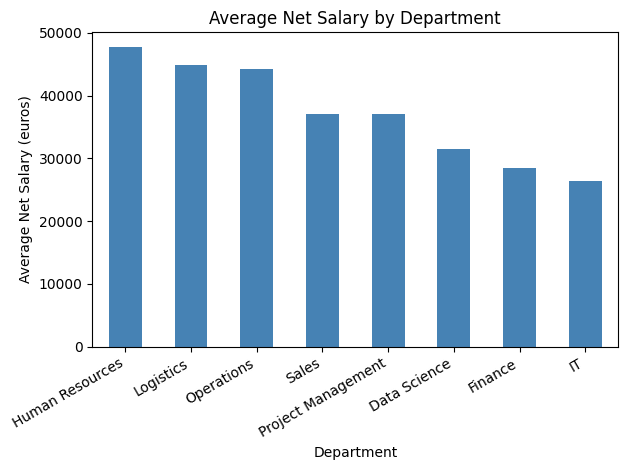

In [44]:
# Step 4 — plot
avg_by_dept_sorted.plot(kind="bar", color="steelblue")

plt.title("Average Net Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Net Salary (euros)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 4.2 — Fair comparison: same level, different departments

In [47]:
# Example — Analysts (level 4) across departments
# Same role, different teams — this is a fair comparison
analysts = hr[hr["level"] == 4]

analyst_by_dept = analysts.groupby("department_name")["net_salary"].mean().round(0)
print("Average net salary — Analysts only:")
print(analyst_by_dept.sort_values(ascending=False).to_string())

Average net salary — Analysts only:
department_name
Data Science    38193.0
Finance         38148.0
Logistics       36465.0
Operations      35213.0


In [48]:
analysts.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary,position_name,level,salary_band_min,salary_band_max,department_name,area,cost_center
11,R0012,W006,D03,P05,2018,47400.0,3400.0,1200,52000.0,16640.0,35360.0,Analyst,4,44000,56000,Logistics,Operations,CC-103
12,R0013,W006,D03,P05,2019,49400.0,1300.0,2400,53100.0,16992.0,36108.0,Analyst,4,44000,56000,Logistics,Operations,CC-103
13,R0014,W006,D03,P05,2020,51300.0,1300.0,1200,53800.0,17216.0,36584.0,Analyst,4,44000,56000,Logistics,Operations,CC-103
14,R0015,W006,D03,P05,2021,52700.0,1700.0,1200,55600.0,17792.0,37808.0,Analyst,4,44000,56000,Logistics,Operations,CC-103
27,R0028,W010,D05,P05,2021,46900.0,1500.0,0,48400.0,15488.0,32912.0,Analyst,4,44000,56000,Operations,Operations,CC-105


### Your turn — same comparison for Managers (level 6)

In [53]:
# Step 1 — filter managers
# Hint: df[df["col"] == value]
managers = hr[hr["level"] == 6]
managers.head()


,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary,position_name,level,salary_band_min,salary_band_max,department_name,area,cost_center
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0,Manager,6,66000,88000,Sales,Commercial,CC-104
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0,Manager,6,66000,88000,Sales,Commercial,CC-104
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,54994.0,Manager,6,66000,88000,Sales,Commercial,CC-104
21,R0022,W007,D02,P08,2021,76600.0,8600.0,6000,91200.0,34656.0,56544.0,Manager,6,66000,88000,Human Resources,Business,CC-102
22,R0023,W007,D02,P08,2022,80400.0,5200.0,9600,95200.0,36176.0,59024.0,Manager,6,66000,88000,Human Resources,Business,CC-102


In [55]:
# Step 2 — average by department
# Hint: df.groupby("col")["col"].mean().round(0)
manager_by_dept = managers.groupby("department_name")["net_salary"].mean().round(0)
manager_by_dept.head()



department_name
Data Science       53010.0
Human Resources    58675.0
Logistics          57598.0
Sales              55658.0
Name: net_salary, dtype: float64

In [58]:
# Step 3 — sort
# Hint: df.sort_values(ascending=False)
manager_by_dept_sorted = manager_by_dept.sort_values(ascending=False)
manager_by_dept_sorted.head()

department_name
Human Resources    58675.0
Logistics          57598.0
Sales              55658.0
Data Science       53010.0
Name: net_salary, dtype: float64

In [57]:
# Step 4 — print
print("Average net salary — Managers only:")
print(manager_by_dept_sorted)

Average net salary — Managers only:
department_name
Human Resources    58675.0
Logistics          57598.0
Sales              55658.0
Data Science       53010.0
Name: net_salary, dtype: float64


## 4.3 — Salary by area

In [59]:
# Step 1 — calculate
# Hint: df.groupby("col")["col"].mean().round(0)
avg_by_area = hr.groupby("area")["net_salary"].mean().round(0)
avg_by_area.head()



area
Business      40092.0
Commercial    37137.0
Operations    44561.0
Technology    29536.0
Name: net_salary, dtype: float64

In [60]:
# Step 2 — sort
avg_by_area_sorted = avg_by_area.sort_values(ascending=False)
avg_by_area_sorted.head()



area
Operations    44561.0
Business      40092.0
Commercial    37137.0
Technology    29536.0
Name: net_salary, dtype: float64

In [61]:
# Step 3 — print
print("Average net salary by area:")
print(avg_by_area_sorted)

Average net salary by area:
area
Operations    44561.0
Business      40092.0
Commercial    37137.0
Technology    29536.0
Name: net_salary, dtype: float64


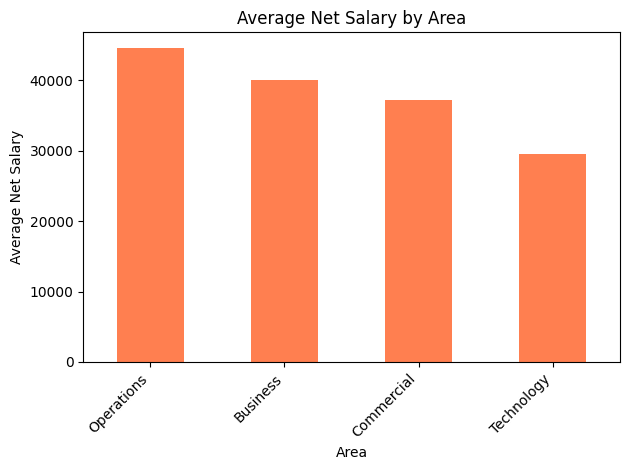

In [64]:
# Step 4 — plot
avg_by_area_sorted.plot(kind="bar", color="coral")

plt.title("Average Net Salary by Area")
plt.xlabel("Area")
plt.ylabel("Average Net Salary")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 5. Salary Evolution Over Time
No new join needed here — year is already in the fact table.

> *"If we hired many junior workers in 2023, the overall average drops —
> not because salaries went down, but because the mix changed."*

In [65]:
# Overall average per year
avg_by_year = hr.groupby("year")["net_salary"].mean().round(0)

print("Average net salary per year:")
print(avg_by_year.to_string())

Average net salary per year:
year
2018    33322.0
2019    31286.0
2020    32859.0
2021    36649.0
2022    42345.0
2023    42231.0
2024    39619.0


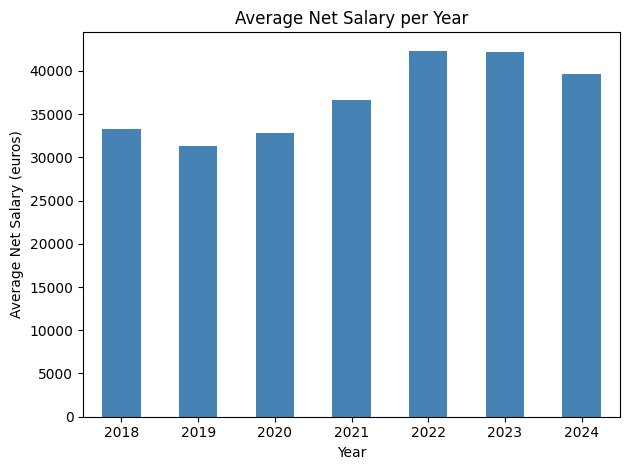


Does this mean salaries went up or down?
Or did the position mix change?


In [66]:
# Plot it
avg_by_year.plot(kind="bar", color="steelblue")

plt.title("Average Net Salary per Year")
plt.xlabel("Year")
plt.ylabel("Average Net Salary (euros)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
print()
print("Does this mean salaries went up or down?")
print("Or did the position mix change?")

In [67]:
hr.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary,position_name,level,salary_band_min,salary_band_max,department_name,area,cost_center
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,51274.0,Manager,6,66000,88000,Sales,Commercial,CC-104
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,53878.0,Manager,6,66000,88000,Sales,Commercial,CC-104
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,54994.0,Manager,6,66000,88000,Sales,Commercial,CC-104
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,15222.0,Working Student,1,14000,20000,Data Science,Technology,CC-108
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,15824.0,Working Student,1,14000,20000,Data Science,Technology,CC-108


### Your turn — Senior Analysts only (fair time comparison)

In [69]:
# Step 1 — filter Senior Analysts
# Hint: df[df["col"] == "value"]
senior_analysts = hr[hr["position_name"] == "Senior Analyst"]
senior_analysts.head()



,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,net_salary,position_name,level,salary_band_min,salary_band_max,department_name,area,cost_center
6,R0007,W004,D07,P06,2020,58900.0,2500.0,1200,62600.0,20032.0,42568.0,Senior Analyst,5,54000,68000,Project Management,Business,CC-107
7,R0008,W004,D07,P06,2021,60700.0,1900.0,2400,65000.0,20800.0,44200.0,Senior Analyst,5,54000,68000,Project Management,Business,CC-107
15,R0016,W006,D03,P06,2022,59000.0,1100.0,0,60100.0,19232.0,40868.0,Senior Analyst,5,54000,68000,Logistics,Operations,CC-103
16,R0017,W006,D03,P06,2023,61300.0,2400.0,0,63700.0,20384.0,43316.0,Senior Analyst,5,54000,68000,Logistics,Operations,CC-103
17,R0018,W006,D03,P06,2024,63600.0,3100.0,2400,69100.0,22112.0,46988.0,Senior Analyst,5,54000,68000,Logistics,Operations,CC-103


In [ ]:
# Step 2 — average per year
# Hint: df.groupby("col")["col"].mean().round(0)
sa_by_year = senior_analysts.groupby("year")["net_salary"].mean().round(0)



In [76]:
# Step 3 — print
print("Senior Analyst — average net salary per year:")
print(sa_by_year)

Senior Analyst — average net salary per year:
year
2018    42126.0
2019    43826.0
2020    43231.0
2021    43724.0
2022    43602.0
2023    44298.0
2024    45764.0
Name: net_salary, dtype: float64


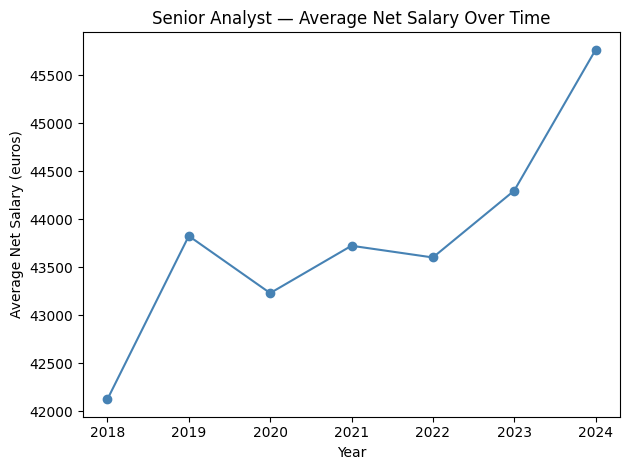

In [74]:
# Line chart — shows growth trend clearly
sa_by_year.plot(kind="line", marker="o", color="steelblue")

plt.title("Senior Analyst — Average Net Salary Over Time")
plt.xlabel("Year")
plt.ylabel("Average Net Salary (euros)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Your turn — line chart per department (salary growth by team)

**Steps:**
1. groupby `year` and `department_name`, calculate mean net_salary
2. unstack to turn departments into columns
3. plot as a line chart

In [88]:
# Step 1 — calculate
# Hint: df.groupby(["col1","col2"])["col"].mean().round(0).unstack()
avg_year_dept = hr.groupby(["year", "area"])["net_salary"].mean().round(0)

# Step 2 — unstack turns departments into columns
avg_year_dept_unstacked = avg_year_dept.unstack()
print(avg_year_dept_unstacked)



area  Business  Commercial  Operations  Technology
year                                              
2018   32642.0         NaN     35360.0         NaN
2019   29826.0     40609.0     36108.0     26385.0
2020   33154.0     32693.0     35826.0     30648.0
2021   39923.0     36593.0     38584.0     30331.0
2022   45866.0     40874.0     48172.0     30276.0
2023   48152.0     37478.0     48933.0     29397.0
2024   42235.0     35608.0     45711.0     28680.0


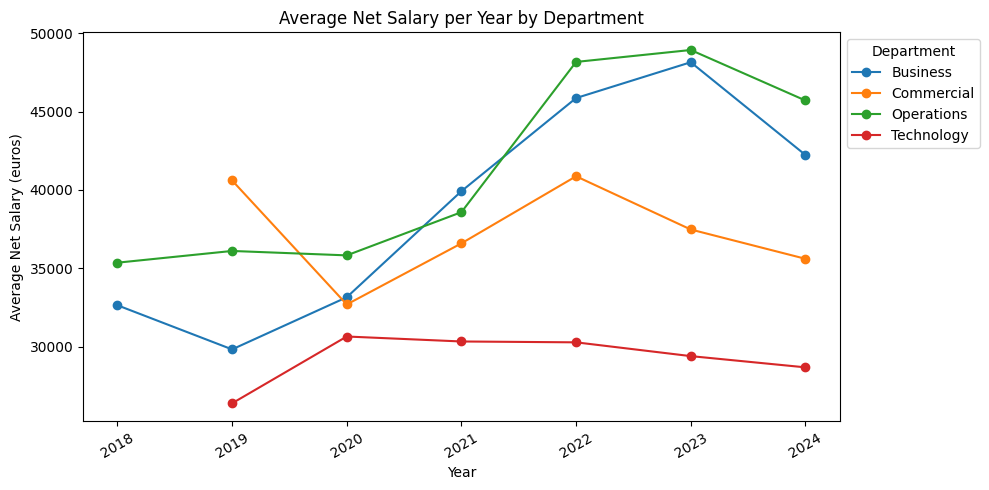

In [89]:
# Step 3 — plot
avg_year_dept_unstacked.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Average Net Salary per Year by Department")
plt.xlabel("Year")
plt.ylabel("Average Net Salary (euros)")
plt.xticks(rotation=30)
plt.legend(title="Department", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# 6. Career Progression — Who Got Promoted?
To show names in the career path, we need to join the workers table now.

The fact table records which position each worker had each year.
If a worker has different `position_id` values across years — they were promoted.

In [92]:
# Join workers — we need full_name and years_at_company now
# Hint: df.merge(other_df, on="shared_col", how="left")
hr = hr.merge(
    workers[["worker_id", "full_name", "years_at_company"]],
    on="worker_id",
    how="left"
)

print("After joining workers:")


hr.head()

After joining workers:


,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,...,salary_band_max,department_name,area,cost_center,full_name_x,years_at_company_x,full_name_y,years_at_company_y,full_name,years_at_company
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,...,20000,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,...,20000,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2


In [94]:
# Count positions per worker — more than 1 means promoted
positions_per_worker = hr.groupby("worker_id")["position_id"].nunique()
positions_per_worker.head()

worker_id
W001    1
W002    1
W003    1
W004    1
W005    1
Name: position_id, dtype: int64

In [96]:
promoted     = positions_per_worker[positions_per_worker > 1]
promoted.head()

worker_id
W006    2
W007    3
W012    2
W013    2
W014    2
Name: position_id, dtype: int64

In [ ]:
# Count positions per worker — more than 1 means promoted
positions_per_worker = hr.groupby("worker_id")["position_id"].nunique()
positions_per_worker.head()

promoted     = positions_per_worker[positions_per_worker > 1]
not_promoted = positions_per_worker[positions_per_worker == 1]

print("Workers promoted at least once:", len(promoted))
print("Workers with no promotion:     ", len(not_promoted))
print()
print("Promotions count:")
print(promoted.value_counts().sort_index())
print()
print("2 = promoted once, 3 = promoted twice, etc.")

Workers promoted at least once: 10
Workers with no promotion:      30

Promotions count:
position_id
2    9
3    1
Name: count, dtype: int64

2 = promoted once, 3 = promoted twice, etc.


### Your turn — top 3 most promoted workers

In [97]:
# Hint: df.nlargest(n, series_name) — or sort and head
top_promoted = positions_per_worker.nlargest(3)

print("Most promoted workers:")
print(top_promoted.to_string())

Most promoted workers:
worker_id
W007    3
W006    2
W012    2


### Your turn — career path of one specific worker

In [100]:
# Pick a worker_id from the promoted list above
worker_id_to_check = "W007"

# Filter — one specific worker
# Hint: df[df["col"] == variable]
career = hr[hr["worker_id"] == worker_id_to_check]

# Show progression
print("Career path:")
print(career[["year", "position_name", "level", "base_salary", "net_salary"]].to_string(index=False))

Career path:
 year  position_name  level  base_salary  net_salary
 2018 Senior Analyst      5      58500.0     42024.0
 2019 Senior Analyst      5      61100.0     44948.0
 2020    Coordinator      5      68400.0     44764.0
 2021        Manager      6      76600.0     56544.0
 2022        Manager      6      80400.0     59024.0
 2023        Manager      6      83100.0     59102.0
 2024        Manager      6      87000.0     60030.0


In [101]:
# See multiple workers at once — using a list of IDs
# Hint: df[df["col"].isin(["val1", "val2", "val3"])]
workers_to_check = ["W007", "W008", "W009"]

careers = hr[hr["worker_id"].isin(workers_to_check)]

# Sort so each worker's years appear together
# Hint: df.sort_values(["col1", "col2"])
careers_sorted = careers.sort_values(["worker_id", "year"])

print("Career paths — multiple workers:")
print(careers_sorted[["worker_id", "full_name", "year", "position_name", "level", "net_salary"]].to_string(index=False))

Career paths — multiple workers:
worker_id      full_name  year   position_name  level  net_salary
     W007 Lukas Hartmann  2018  Senior Analyst      5     42024.0
     W007 Lukas Hartmann  2019  Senior Analyst      5     44948.0
     W007 Lukas Hartmann  2020     Coordinator      5     44764.0
     W007 Lukas Hartmann  2021         Manager      6     56544.0
     W007 Lukas Hartmann  2022         Manager      6     59024.0
     W007 Lukas Hartmann  2023         Manager      6     59102.0
     W007 Lukas Hartmann  2024         Manager      6     60030.0
     W008   Max Hoffmann  2024 Working Student      1     14620.0
     W009     Bob Krüger  2024 Working Student      1     14620.0


In [ ]:
# See a range of workers — W001 to W010
# Hint: df[df["col"].between("val1", "val2")] works on strings too
careers_range = hr[hr["worker_id"].between("W001", "W010")]

careers_range_sorted = careers_range.sort_values(["worker_id", "year"])

print("Career paths — W001 to W010:")
print(careers_range_sorted[["worker_id", "full_name", "year", "position_name", "net_salary"]].to_string(index=False))

# 7. Tenure Analysis — Do Workers Who Stay Longer Earn More?
Workers table already joined — `years_at_company` is available.

> *"Workers who stay longer might earn more — but is that because of tenure itself,
> or simply because they got promoted over time?
> Always check the confounding variable."*

In [103]:
hr.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,...,salary_band_max,department_name,area,cost_center,full_name_x,years_at_company_x,full_name_y,years_at_company_y,full_name,years_at_company
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,...,88000,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,...,20000,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,...,20000,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2


In [104]:
# Step 1 — create tenure groups on the WORKERS table
# Important: workers has one row per person — no double counting
# We classify tenure here, then join back to hr

def classify_tenure(years):
    if years <= 2:
        return "0-2 years"
    elif years <= 4:
        return "2-4 years"
    elif years <= 6:
        return "4-6 years"
    else:
        return "6+ years"

# Apply to workers — one row per person
# Hint: df["col"].apply(function_name)
workers["tenure_group"] = workers["years_at_company"].apply(classify_tenure)

# Check distribution — this counts PEOPLE, not rows
# Hint: df["col"].value_counts().sort_index()
tenure_counts = workers["tenure_group"].value_counts().sort_index()
print("People per tenure group:")
print(tenure_counts)
print()
print("This counts people — not salary records")
print("Each person appears exactly once here")

People per tenure group:
tenure_group
0-2 years     3
2-4 years     8
4-6 years    16
6+ years     13
Name: count, dtype: int64

This counts people — not salary records
Each person appears exactly once here


In [105]:
# Step 2 — join tenure_group back to hr fact table
# Now each salary record has the worker's tenure group
# Hint: df.merge(other_df, on="shared_col", how="left")
hr = hr.merge(
    workers[["worker_id", "tenure_group"]],
    on="worker_id",
    how="left"
)

print("tenure_group added to hr:")
print(hr[["worker_id", "year", "position_name", "tenure_group", "net_salary"]].head(8))

tenure_group added to hr:
  worker_id  year    position_name tenure_group  net_salary
0      W001  2022          Manager    4-6 years     51274.0
1      W001  2023          Manager    4-6 years     53878.0
2      W001  2024          Manager    4-6 years     54994.0
3      W002  2023  Working Student    2-4 years     15222.0
4      W002  2024  Working Student    2-4 years     15824.0
5      W003  2024  Working Student    0-2 years     15136.0
6      W004  2020   Senior Analyst     6+ years     42568.0
7      W004  2021   Senior Analyst     6+ years     44200.0


In [106]:
hr.head()

,record_id,worker_id,department_id,position_id,year,base_salary,bonus,additional_allowance,gross_total,taxes,...,department_name,area,cost_center,full_name_x,years_at_company_x,full_name_y,years_at_company_y,full_name,years_at_company,tenure_group
0,R0001,W001,D04,P08,2022,69500.0,7200.0,6000,82700.0,31426.0,...,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1,4-6 years
1,R0002,W001,D04,P08,2023,72500.0,7200.0,7200,86900.0,33022.0,...,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1,4-6 years
2,R0003,W001,D04,P08,2024,74800.0,4300.0,9600,88700.0,33706.0,...,Sales,Commercial,CC-104,Alice Wagner,4.1,Alice Wagner,4.1,Alice Wagner,4.1,4-6 years
3,R0004,W002,D08,P02,2023,15300.0,0.0,2400,17700.0,2478.0,...,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2,2-4 years
4,R0005,W002,D08,P02,2024,16000.0,0.0,2400,18400.0,2576.0,...,Data Science,Technology,CC-108,Tina Becker,3.2,Tina Becker,3.2,Tina Becker,3.2,2-4 years


In [107]:
# Step 2 — average salary per tenure group (naive first)
# Hint: df.groupby("col")["col"].mean().round(0)
avg_by_tenure = hr.groupby("tenure_group")["net_salary"].mean().round(0)

# Sort so groups appear in order
avg_by_tenure_sorted = avg_by_tenure.sort_index()

# Print
print("Average net salary by tenure group:")
print(avg_by_tenure_sorted)
print()
print("Does longer tenure mean higher salary?")

Average net salary by tenure group:
tenure_group
0-2 years    14792.0
2-4 years    34234.0
4-6 years    43519.0
6+ years     35667.0
Name: net_salary, dtype: float64

Does longer tenure mean higher salary?


In [108]:
# Step 3 — average salary per tenure group AND year
# We include year in the groupby — avoids comparing different time periods
# Hint: df.groupby(["col1","col2"])["col"].mean().round(0).unstack()
avg_tenure_year = hr.groupby(["tenure_group", "year"])["net_salary"].mean().round(0)

# Unstack so each tenure group becomes a column
avg_tenure_year_unstacked = avg_tenure_year.unstack()

print("Average net salary by year and tenure group:")
print(avg_tenure_year_unstacked)
print()
print("Read across each row — same year, different tenure groups")
print("Does longer tenure mean higher salary within the same year?")

Average net salary by year and tenure group:
year             2018     2019     2020     2021     2022     2023     2024
tenure_group                                                               
0-2 years         NaN      NaN      NaN      NaN      NaN      NaN  14792.0
2-4 years         NaN      NaN      NaN      NaN  51241.0  31961.0  29846.0
4-6 years         NaN      NaN  32147.0  38102.0  43941.0  47969.0  49017.0
6+ years      33322.0  31286.0  33242.0  35076.0  36721.0  40459.0  42256.0

Read across each row — same year, different tenure groups
Does longer tenure mean higher salary within the same year?


### Your turn — fair comparison: same level, different tenure

**What to do:**
1. groupby `level` and `tenure_group` together
2. calculate average `net_salary` per group
3. sort by index so levels appear in order
4. read the output — for the same level, do different tenure groups earn differently

In [110]:
# Step 4 — average level per tenure group AND year
# Hint: df.groupby(["col1","col2"])["col"].mean().round(1).unstack()
avg_level_tenure = hr.groupby(["tenure_group", "level"])["net_salary"].mean().round(1)

avg_level_tenure_unstacked = avg_level_tenure.unstack()

print("Average position level by year and tenure group:")
print(avg_level_tenure_unstacked)
print()
print("If longer tenure = higher level in the same year")
print("the salary difference is about promotions, not tenure itself")

Average position level by year and tenure group:
level               1        2        3        4        5        6        7  \
tenure_group                                                                  
0-2 years     14792.0      NaN      NaN      NaN      NaN      NaN      NaN   
2-4 years     15241.1      NaN      NaN      NaN  42228.0  57598.0  59856.0   
4-6 years     14549.6  24396.0  29081.3  37001.1  43935.6  53196.0  62661.8   
6+ years      14599.3  25817.2  28984.0  36801.6  43701.7  57757.6  66526.0   

level               8  
tenure_group           
0-2 years         NaN  
2-4 years         NaN  
4-6 years     81925.0  
6+ years          NaN  

If longer tenure = higher level in the same year
the salary difference is about promotions, not tenure itself


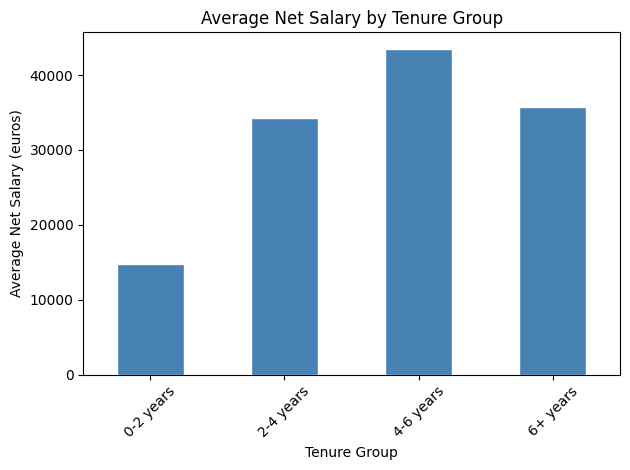

In [115]:
# Step 5 — visualise
avg_by_tenure_sorted.plot(kind="bar", color="steelblue", edgecolor="white")

plt.title("Average Net Salary by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Average Net Salary (euros)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Step 5 — fair comparison: same level, same year, different tenure
# Hint: df.groupby(["col1","col2","col3"])["col"].mean().round(0)
tenure_by_level_year = hr.groupby(["____", "_____", "____________"])["__________"].______().round(0)

tenure_by_level_year_sorted = tenure_by_level_year.sort_index()

print("Average net salary by year, level AND tenure group:")
print(tenure_by_level_year_sorted.to_string())
print()
print("Same year, same level, different tenure — is there still a difference?")

In [ ]:
# Challenge 1 — which worker earned the most in total across all years?

# Step 1 — group by worker and calculate total earnings
# Hint: df.groupby(["col1","col2"]).agg(new_col=("col","function"))
total_by_worker = hr.groupby(["_________", "__________"]).agg(
    total_net_salary = ("__________", "___"),
    years_in_data    = ("____",       "________")
).round(0)

print("Total earnings per worker:")
print(total_by_worker.head(5))

In [ ]:
# Step 2 — find the top 5 using nlargest
# Hint: df.nlargest(n, "col")
top_earners = _______________.____________(___, "________________")

print("Top 5 total earners:")
print(top_earners.to_string())

## Challenge 2 — Department with highest average bonus
Which department pays the highest average bonus?
Is it explained by position level?

**Hint:** groupby department, mean bonus AND mean level — compare both rankings

In [ ]:
# Challenge 2 — which department pays the highest average bonus?
# And is it explained by position level?

# Step 1 — average bonus per department
# Hint: df.groupby("col")["col"].mean().round(0)
bonus_by_dept = ____________.__________("_______________")["_____"].______().round(0)

print("Average bonus by department:")
print(_______________)

In [ ]:
# Step 2 — average position level per department
# Hint: df.groupby("col")["col"].mean().round(1)
level_by_dept = hr.groupby("_______________")["_____"].______().round(1)

print("Average level by department:")
print(_______________)

In [ ]:
# Step 3 — combine both into one summary table
# Hint: pd.DataFrame({"col1": series1, "col2": series2})
summary = pd.DataFrame({
    "avg_bonus": _______________,
    "avg_level": _______________
})

# Step 4 — sort by bonus highest first
# Hint: df.sort_values("col", ascending=False)
summary_sorted = summary.sort_values("___________", ascending=_______)

# Step 5 — print
print("Bonus and level by department:")
print(_______________)
print()
print("Does the department with the highest bonus also have the highest level?")
print("If yes — the bonus difference is explained by seniority, not the department")

## Challenge 3 — Hires per year
How many workers were hired each year?
Plot a bar chart.

**Hint:** use `workers["admission_date"]` — convert to datetime, extract year, value_counts

In [ ]:
# Challenge 3 — how many workers were hired each year?

# Step 1 — convert admission_date to datetime
# Hint: pd.to_datetime(df["col"])
workers["admission_date"] = pd.to_datetime(workers["_______________"])

print("Date column converted:")
print(workers["admission_date"].head(5))

In [ ]:
# Step 2 — extract the year from admission_date
# Hint: df["date_col"].dt.year
workers["admission_year"] = ["_______________"].dt.____

print("Admission year — first 5 rows:")
print(workers[["full_name", "admission_date", "admission_year"]].head(5))

In [ ]:
# Step 3 — count workers hired per year
# Hint: df["col"].value_counts().sort_index()
hires_per_year =

print("Hires per year:")
print(_______________)

In [ ]:
# Step 4 — plot a bar chart
# Hint: df.plot(kind="bar", color="steelblue")
____________.plot(kind="___", color="steelblue")

plt.title("___")
plt.xlabel("Year")
plt.ylabel("___")
plt.xticks(rotation=___)

plt.tight_layout()
plt.show()

print()
print("Which year had the most hires? ___")
print("Which year had the fewest? ___")

# Answers — only open after you tried!

In [ ]:
# Challenge 1 — highest total earnings
total_by_worker = hr.groupby(["worker_id", "full_name"]).agg(
    total_net_salary = ("net_salary", "sum"),
    years_in_data    = ("year",       "nunique")
).round(0)

top_earner = total_by_worker.nlargest(5, "total_net_salary")
print("Top 5 total earners:")
print(top_earner.to_string())

In [ ]:
# Challenge 2 — bonus by department
bonus_by_dept = hr.groupby("department_name")["bonus"].mean().round(0)
level_by_dept = hr.groupby("department_name")["level"].mean().round(1)

summary = pd.DataFrame({
    "avg_bonus": bonus_by_dept,
    "avg_level": level_by_dept
}).sort_values("avg_bonus", ascending=False)

print("Bonus and level by department:")
print(summary.to_string())

In [ ]:
# Challenge 3 — hires per year
workers["admission_date"] = pd.to_datetime(workers["admission_date"])
workers["admission_year"] = workers["admission_date"].dt.year

hires = workers["admission_year"].value_counts().sort_index()

hires.plot(kind="bar", color="steelblue")
plt.title("Workers Hired per Year")
plt.xlabel("Year")
plt.ylabel("Number of Hires")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(hires.to_string())